<a href="https://colab.research.google.com/github/yc386/paasta_2026_denovo/blob/main/paasta_denovo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/PAASTA-community/paasta-community.github.io/blob/master/assets/media/paasta_no_bg.png?raw=1" width="180" height="85">
<img src="https://github.com/yc386/forked_pasta/blob/master/assets/media/summer_school.png?raw=1" width="460" height="80">


# *De novo* sequencing: from a PRIDE `.raw` file to annotated spectra

This is a 45-minute practical that walks you through the following:

1. **Fetch** a Thermo `.raw` file from the PRIDE FTP archive
2. **Convert** `.raw` → `mzML` with **ThermoRawFileParser**
3. **Parse** the `mzML` into a `parquet` for **InstaNovo** CLI and a `mgf` for their Hugging Face space
4. ***De Novo*** the spectra with **InstaNovo**
5. **Inspect** predictions and **annotate** spectra with its predicted b/y ions using **spectrum_utils**

> **Before you start:** set the GPU runtime — *Runtime → Change runtime type → Hardware accelerator → GPU (T4)*

>A Google account may be needed to run notebook cells. You may also click *File → Save a copy in Drive*.

>Our working directory(pwd) is /content/ (default), so no need to mount your own google drive unless you'd like to.

## Step 0 — Setup (run once; the runtime will restart)
**Don't click the prompt when Google asks you to restart, it will be done automatically!**
> When the runtime reconnects you'll see a **"Your session crashed for an unknown reason"** banner — don't be alarmed, that's just os.kill & restarting. **Don't re-run the pip install cell;** continue from the GPU check below.

In [ ]:
#@title pip install cell (takes c.5 mins)
!pip install biopython "instanovo[cu126]" pyteomics psims lxml polars pyarrow spectrum_utils

!pip uninstall -y -q torch torchvision torchaudio
!pip install --no-cache-dir torch==2.6.0+cu126 torchvision==0.21.0+cu126 torchaudio==2.6.0+cu126 --index-url https://download.pytorch.org/whl/cu126

import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of boto3 to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of boto3 to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━

Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 136.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 370.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 93.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 198.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 106.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 153.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 165.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 155.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 130.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 185.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 105.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.3/89

In [1]:
#@title >>> After the runtime restarts, start running from **HERE**. Check GPU available for InstaNovo[cu126]<<<
!nvidia-smi -L 2>/dev/null || echo "No GPU -> Runtime > Change runtime type > GPU"
import torch
print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())

GPU 0: Tesla T4 (UUID: GPU-6256c7cb-e674-8b7b-e5d9-2c9ecc049fa8)
torch: 2.6.0+cu126 | CUDA available: True


## Step 1 — Fetch a .raw file from PRIDE

Every PRIDE project has a predictable FTP path:

```
https://ftp.pride.ebi.ac.uk/pride/data/archive/<year>/<month>/<accession>/
```
We are going to download a small file from [PXD058287](https://ftp.pride.ebi.ac.uk/pride/data/archive/2025/09/PXD058287/):
```
20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3.raw (179.7 MB, downloading time: around 1 min)
```

In [2]:
import os, requests

ACCESSION = "PXD058287"
YEAR, MONTH = "2025", "09"
RAW_NAME = "20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3.raw"
URL = f"https://ftp.pride.ebi.ac.uk/pride/data/archive/{YEAR}/{MONTH}/{ACCESSION}/{RAW_NAME}"
RAW_PATH = RAW_NAME

if not os.path.exists(RAW_PATH):
    print("Downloading", URL)
    with requests.get(URL, stream=True, timeout=120) as r:
        r.raise_for_status()
        with open(RAW_PATH, "wb") as f:
            for chunk in r.iter_content(1 << 20):
                f.write(chunk)
print("RAW size (MB):", round(os.path.getsize(RAW_PATH) / 1e6, 1))

RAW size (MB): 179.7


## Step 2 — Convert Thermo .raw → mzML
`.raw` is Thermo's vendor specific (closed) format. **[ThermoRawFileParser](https://github.com/compomics/ThermoRawFileParser)** is an open-source parser that runs on all platforms to convert `.raw` to open formats: `mzML`/`MGF`. We are using `v.2.0.0-dev` without `Mono` dependency.
> -f=0|1|2|3|4, 0 for `MGF`, 1 for `mzML`(plain), 2 for `indexed mzML`

In [3]:
!wget -q https://github.com/CompOmics/ThermoRawFileParser/releases/download/v.2.0.0-dev/ThermoRawFileParser-v.2.0.0-dev-linux.zip
!unzip -q /content/ThermoRawFileParser-v.2.0.0-dev-linux.zip -d ThermoRawFileParser && rm /content/ThermoRawFileParser-v.2.0.0-dev-linux.zip

In [4]:
raw = "/content/20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3.raw"
format = 2
! /content/ThermoRawFileParser/ThermoRawFileParser -i "{raw}" -f "{format}" -z

=2026-06-09 08:26:54 INFO Started parsing /content/20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3.raw
2026-06-09 08:26:55 INFO Processing 9917 MS scans
10% 20% 30% 40% 50% 60% 70% 80% 90% 100% 

2026-06-09 08:27:13 INFO Finished parsing /content/20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3.raw
2026-06-09 08:27:13 INFO Processing completed 0 errors, 0 warnings


## Step 3 — Parse the mzML
> We are going to see what's inside a `mzML`by using InstaNovo's `SpectrumDataFrame`. `.parquet` is like a '.csv' that is human-readable, but smaller to store and faster to be processed by a computer. We will write a small subset (only 100 spectra) to both `.parquet` and `.mgf` for demo.

In [5]:
import glob
import pandas as pd
from instanovo.utils.data_handler import SpectrumDataFrame

/usr/local/lib/python3.12/dist-packages/psims/mzmlb/writer.py:33: UserWarning: hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.
  warnings.warn(


In [6]:
sdf1 = SpectrumDataFrame.load("/content/20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3.mzML", lazy=False, is_annotated=False)
df = sdf1.to_pandas()
df

,scan_number,sequence,precursor_mass,precursor_mz,precursor_charge,retention_time,mz_array,intensity_array,experiment_name
0,6,,1705.768895,853.891724,2,0.036581,"[115.26212310791016, 120.08121490478516, 138.7...","[1531.368896484375, 3489.806884765625, 1258.18...",20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...
1,7,,948.534520,475.274536,2,0.038742,"[165.88584899902344, 209.11793518066406, 263.7...","[1227.3123779296875, 1877.300537109375, 1068.0...",20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...
2,8,,1722.797826,862.406189,2,0.040933,"[126.2745361328125, 141.3558807373047, 203.858...","[1408.305908203125, 1389.77490234375, 1384.296...",20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...
3,10,,946.509191,474.261871,2,0.048800,"[140.41928100585938, 163.00881958007812, 164.8...","[1225.0076904296875, 1150.8607177734375, 1249....",20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...
4,11,,1316.515007,439.845612,3,0.050944,"[197.87615966796875, 217.11524963378906, 217.1...","[1342.667724609375, 2023.048828125, 2312.31445...",20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...
...,...,...,...,...,...,...,...,...,...
8848,9912,,1344.681859,673.348206,2,20.989186,"[138.70924377441406, 142.66969299316406, 175.1...","[1254.6868896484375, 1189.1654052734375, 2801....",20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...
8849,9913,,2199.497167,1100.755859,2,20.991396,"[116.72489166259766, 125.305419921875, 129.102...","[2026.770751953125, 1864.054931640625, 19027.9...",20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...
8850,9915,,2707.372520,903.464783,3,20.997780,"[112.08741760253906, 115.08692932128906, 116.0...","[18943.978515625, 40424.40625, 16279.294921875...",20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...
8851,9916,,2707.374216,677.850830,4,20.999775,"[113.07140350341797, 115.08699035644531, 115.2...","[1802.820556640625, 5978.1865234375, 2276.2854...",20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...


In [7]:
df1 = df.head(100)
df1.to_parquet('head_100.parquet')

In [8]:
from pyteomics import mgf
import numpy as np

def df_to_mgf(df, out_path):
    spectra = []
    for _, row in df.iterrows():
        params = {
            "title":       f"{row['experiment_name']}:scan:{int(row['scan_number'])}",
            "pepmass":     float(row["precursor_mz"]),
            "charge":      f"{int(row['precursor_charge'])}+",
            "rtinseconds": float(row["retention_time"]) * 60.0,
            "scans":       int(row["scan_number"]),
        }
        seq = row.get("sequence")
        if seq is not None and str(seq).strip() not in ("", "nan", "None"):
            params["seq"] = str(seq)

        spectra.append({
            "m/z array":       np.asarray(row["mz_array"],        dtype=float),
            "intensity array": np.asarray(row["intensity_array"], dtype=float),
            "params":          params,
        })

    mgf.write(spectra, out_path, file_mode="w")
    return out_path

In [9]:
df_to_mgf(df1, "head_100.mgf")

'head_100.mgf'

## Step 4 — Run InstaNovo for *de novo*
**[InstaNovo](https://github.com/instadeepai/InstaNovo)** is a transformer that is well-annotated and easy to run. We are going to use just the transformer option this time (without diffusion refinement).
>
- option A: For Google account users, you may run it here using the CLI (commend line interface).
- option B: Go to InstaNovo [Hugging Face space](https://huggingface.co/spaces/InstaDeepAI/InstaNovo) and run the `head_100.mgf` we made in Step 3 online. <br />(note **not the `.mzML`** since it may be too big)

In [10]:
!instanovo predict --help

                                                                                
 Usage: instanovo predict [OPTIONS] [OVERRIDES]...                              
                                                                                
 Run predictions with InstaNovo and optionally refine with InstaNovo+.          
                                                                                
 First with the transformer-based InstaNovo model and then optionally refine    
 them with the diffusion based InstaNovo+ model.                                
                                                                                
╭─ Options ────────────────────────────────────────────────────────────────────╮
│ --data-path             -d                      TEXT  Path to input data     │
│                                                       file                   │
│ --output-path           -o                      FILE  Path to output file.   │
│ --instanovo-model       -i

In [11]:
!instanovo predict --data-path head_100.parquet --output-path preds.csv --denovo --no-refinement

[06/09/26 08:28:20] INFO     Initializing InstaNovo inference.                                                                                                                 
[06/09/26 08:28:23] INFO     NumExpr defaulting to 2 threads.                                                                                                                  
2026-06-09 08:28:29.042133: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
DEBUG:2026-06-09 08:28:31,667:jax._src.path:41: etils.epath found. Using etils.epath for file I/O.
/usr/local/lib/python3.12/dist-packages/psims/mzmlb/writer.py:33: UserWarning: hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.
  warnings.warn(


## Step 5 — Inspect predictions and annotate spectra
> We will pick *de novo* predictions from a list of top and bottom 10 spectra (sorted by model confidence), and visualise them using mirrored plots to see if observed b/y ions matched predicted ones. Generally, higher the ion coverage (obeserved/predicted ions), the better.

In [12]:
import matplotlib.pyplot as plt
import spectrum_utils.spectrum as sus
import spectrum_utils.plot as sup
from spectrum_utils import proforma
from spectrum_utils.fragment_annotation import get_theoretical_fragments
%matplotlib inline

==TOP 10 (most confident)==
 scan_number                           predictions  log_probs  model_confidence
         421                            WENGECAQKK  -0.870066          0.418924
         413                            WENGEGMNKK  -3.742693          0.023690
          10                   LPS[UNIMOD:21]PPLVK  -6.271618          0.001889
         306                       WNEEEKKEEEVAQKK  -6.907854          0.001000
         415               EPIDNLT[UNIMOD:21]PEEER  -7.201611          0.000745
         387 GDQPPVSPGT[UNIMOD:21]ALVGSQKEPSEVPTPK  -7.391842          0.000616
         427                                DEALEK  -7.809131          0.000406
         432        ESEDKPEIEDVGS[UNIMOD:21]DEEEEK  -8.665483          0.000172
         391             AEEEDVS[UNIMOD:21]EEEGEEK  -9.293673          0.000092
           7                         IGGGGGGGGGGGR  -9.312765          0.000090

==BOTTOM 10 (least confident)==
 scan_number                                               

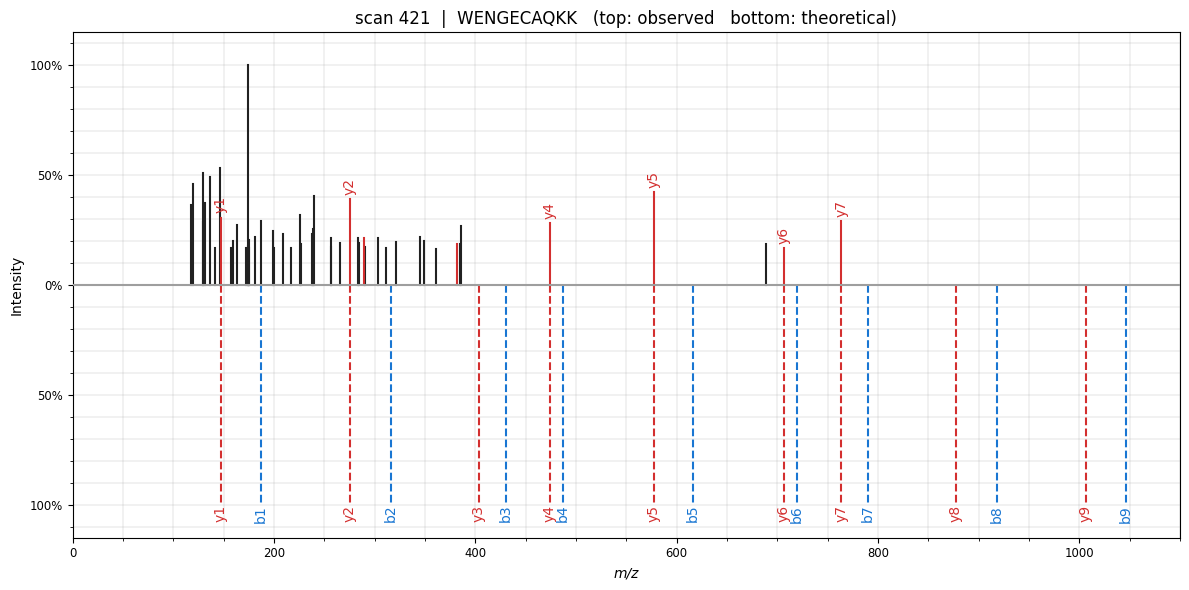

In [25]:
PARQUET = "head_100.parquet"
#change fragment ion tolerance here
TOL, TOL_MODE = 10, "ppm"

preds   = pd.read_csv("preds.csv")
spectra = pd.read_parquet(PARQUET)

seq_col  = next((c for c in ["predictions","prediction","sequence","peptide"] if c in preds.columns), preds.columns[0])
conf_col = next((c for c in ["log_probs","log_probabilities","confidence"] if c in preds.columns), None)
if conf_col is not None:
    preds["model_confidence"] = np.clip(np.exp(preds[conf_col]), 0, 1)

cand = preds.sort_values(conf_col, ascending=False) if conf_col else preds
cols = ["scan_number", seq_col, conf_col, "model_confidence"]

print("==TOP 10 (most confident)==")
print(cand[cols].head(10).to_string(index=False))

print("\n==BOTTOM 10 (least confident)==")
print(cand[cols].tail(10).to_string(index=False))

def show_mirror(scan_number=None):
    """Pass a scan_number from the list above; None = highest confidence."""
    row = cand.iloc[0] if scan_number is None else cand[cand["scan_number"] == scan_number].iloc[0]
    peptide, scan = str(row[seq_col]), int(row["scan_number"])
    sp = spectra.loc[spectra["scan_number"] == scan].iloc[0]
    pmz, z = float(sp["precursor_mz"]), int(sp["precursor_charge"])

    obs = sus.MsmsSpectrum(str(scan), pmz, z,
                           np.asarray(sp["mz_array"], float), np.asarray(sp["intensity_array"], float))
    obs = (obs.set_mz_range(100, 1500).remove_precursor_peak(TOL, TOL_MODE)
              .filter_intensity(0.01, 50).scale_intensity("root")
              .annotate_proforma(peptide, TOL, TOL_MODE, ion_types="by"))

    proteoform = proforma.parse(peptide)[0]
    frags = get_theoretical_fragments(proteoform, ion_types="by", max_charge=1)
    frag_mz = np.array([mz for _, mz in frags])
    theo = sus.MsmsSpectrum(f"{peptide} (theoretical)", pmz, z,
                            frag_mz, np.full(len(frag_mz), obs.intensity.max()))
    theo = theo.annotate_proforma(peptide, TOL, TOL_MODE, ion_types="by")

    fig, ax = plt.subplots(figsize=(12, 6))
    sup.mirror(obs, theo, ax=ax)

    for line in ax.lines:
        yd = line.get_ydata()
        if len(yd) and np.min(yd) < -1e-9:
            line.set_linestyle("--")
    for coll in ax.collections:
        segs = coll.get_segments()
        if segs and min(s[:, 1].min() for s in segs) < -1e-9:
            coll.set_linestyle("--")

    ax.set_title(f"scan {scan}  |  {peptide}   (top: observed   bottom: theoretical)")
    plt.tight_layout(); plt.show()

# highest-confidence prediction
show_mirror()

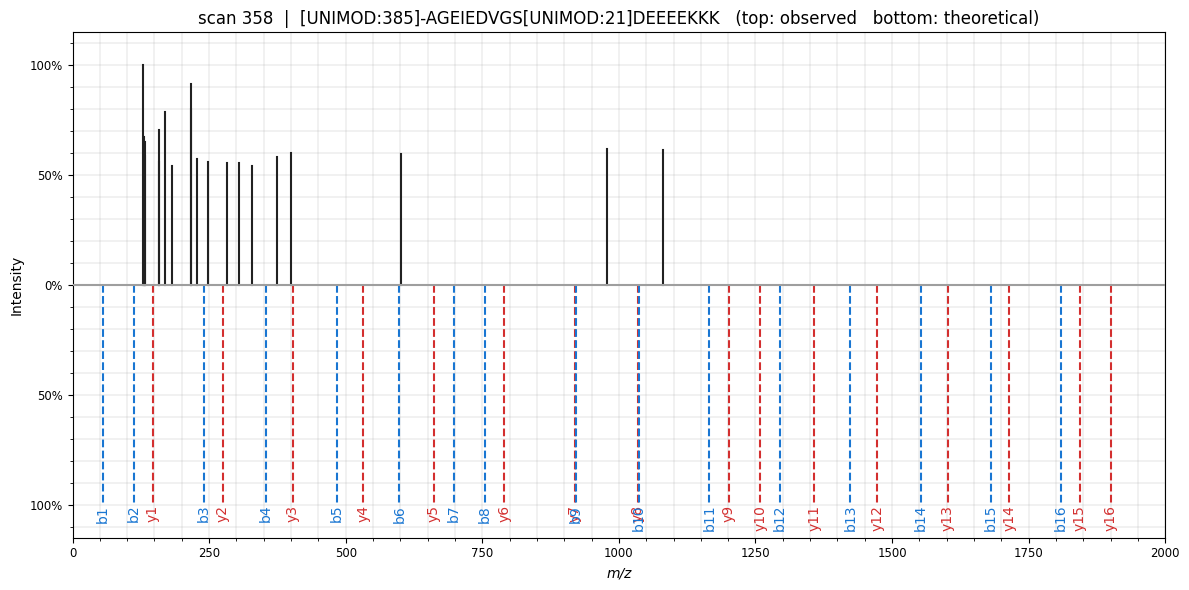

In [ ]:
show_mirror(358)

In [ ]:
preds

,experiment_name,scan_number,spectrum_id,precursor_mz,precursor_charge,prediction_id,predictions,log_probs,token_log_probs,group,...,predictions_log_probability_beam_2,predictions_token_log_probabilities_beam_2,predictions_beam_3,predictions_log_probability_beam_3,predictions_token_log_probabilities_beam_3,predictions_beam_4,predictions_log_probability_beam_4,predictions_token_log_probabilities_beam_4,predictions_tokenised,delta_mass_ppm
0,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,6,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,853.891724,2,0,APEPVY[UNIMOD:21]QEPAFQHL,-17.223223,"[-5.778421401977539, -3.5627429485321045, -0.4...",no_group,...,-14.010789,"[-6.092211723327637, -1.1313897371292114, -0.3...",SGEPVY[UNIMOD:21]QEPAFQHL,-17.044230,"[-3.871582508087158, -6.126219272613525, -0.46...",GPEPVY[UNIMOD:21]QEPAFQHL,-18.257292,"[-6.566995620727539, -3.5627429485321045, -0.4...","A, P, E, P, V, Y[UNIMOD:21], Q, E, P, A, F, Q,...",6.411976
1,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,7,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,475.274536,2,1,IGGGGGGGGGGGR,-9.312765,"[-0.9016326665878296, -0.8665971755981445, -0....",no_group,...,-10.063011,"[-0.03363896906375885, -0.0011342290090397, -0...",GGGGGGGGGGGGGR,-10.908047,"[-0.5797479152679443, -0.7492889165878296, -0....",AGGGGGGGGGGGGR,-13.832644,"[-3.7301385402679443, -0.7492889165878296, -0....","I, G, G, G, G, G, G, G, G, G, G, G, R",34821.233571
2,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,8,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,862.406189,2,2,[UNIMOD:385]-AGATETERNNYSNDPT,-26.158211,"[-11.283747673034668, -3.7726104259490967, -0....",no_group,...,-15.528481,"[-0.5004202723503113, -1.964315414428711, -1.2...",AGSAADFKNNYSNDPT,-18.210447,"[-4.297783374786377, -1.964315414428711, -1.29...",DGSAADFKNNYSNDPT,-18.631748,"[-4.146904468536377, -1.964315414428711, -1.29...","[UNIMOD:385], A, G, A, T, E, T, E, R, N, N, Y,...",47.298437
3,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,10,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,474.261871,2,3,LPS[UNIMOD:21]PPLVK,-6.271618,"[-0.02569507248699665, -0.2261984646320343, -0...",no_group,...,-13.432164,"[-1.5742056369781494, -0.7604012489318848, -0....",PEPLGPPVK,-15.468118,"[-1.0271492004394531, -1.463897466659546, -0.0...",PLPGPPLVK,-16.543262,"[-1.1035025119781494, -0.7604012489318848, -0....","L, P, S[UNIMOD:21], P, P, L, V, K",16876.135995
4,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,11,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,439.845612,3,4,KGEPPAPKS[UNIMOD:21]PPK,-15.222504,"[-2.568951368331909, -0.025438154116272926, -0...",no_group,...,-18.021221,"[-2.321755886077881, -1.8196910619735718, -0.7...",SGSAAAKPPS[UNIMOD:21]PEK,-18.332724,"[-1.3700376749038696, -2.2933239936828613, -0....",PGSAAAKPPS[UNIMOD:21]PEK,-19.702961,"[-1.7567564249038696, -2.2933239936828613, -0....","K, G, E, P, P, A, P, K, S[UNIMOD:21], P, P, K",2920.076663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,428,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,952.077393,3,95,GEGDPSQEAPVLVDGVGLVELIEELLR,-32.333275,"[-1.8170156478881836, -1.2750786542892456, -2....",no_group,...,-34.598511,"[-3.0230703353881836, -1.2750786542892456, -2....",APGDPSQEAPVLVDGVGLVELIEELLR,-35.061409,"[-3.307000160217285, -1.0543755292892456, -2.8...",PPGDPSQEAPVLVDGVGLVELIEELLR,-37.301590,"[-2.770867347717285, -1.0543755292892456, -2.8...","G, E, G, D, P, S, Q, E, A, P, V, L, V, D, G, V...",6908.154697
96,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,429,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,973.078247,3,96,[UNIMOD:385]-NEEDEEDKEVDEES[UNIMOD:21]EDEEASQLEK,-37.483696,"[-17.631580352783203, -4.467278480529785, -0.0...",no_group,...,-42.647240,"[-17.74674415588379, -5.252480983734131, -4.26...",GEEEDEEEEDDEES[UNIMOD:21]EDEEASQLEK,-23.321966,"[-3.340639114379883, -0.0433836355805397, -0.1...",GEEEEEEKEVDEES[UNIM